In [7]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
import pandas as pd

# Spécifiez le chemin du fichier Excel
chemin_fichier_excel = "FOOD_tweets.xlsx"

# Utilisez la fonction read_excel de pandas pour lire le fichier
df = pd.read_excel(chemin_fichier_excel)

# Affichez les premières lignes du DataFrame pour vérifier que les données ont été chargées correctement
df.head()

,Name,Handle,Timestamp,Verified,Content,Comments,Retweets,Likes,Analytics,Tags,Profile Image
0,Sunny,@sunny0_,2023-12-26T17:03:06.000Z,True,KFC Serves #Halal food as per #Sharia Law .\n\...,NaN,NaN,NaN,16,"['#Halal', '#Sharia', '#Sharia', '#Hindus', '#...",https://pbs.twimg.com/profile_images/171105085...
1,stolas brainrot,@snuffysuffy,2023-12-26T17:02:06.000Z,False,"yea I absolutely get what you mean, my point i...",NaN,NaN,1.0,6,[],https://pbs.twimg.com/profile_images/173469407...
2,R,@xRzgdx,2023-12-26T15:24:06.000Z,True,"Lo que pasa en la cocina de kfc,wendys, burger...",NaN,NaN,NaN,44,[],https://pbs.twimg.com/profile_images/147158406...
3,Darth Kothicame,@darthkot97,2023-12-26T15:20:13.000Z,False,"Go for fried foods in outlets like KFC,McD etc...",1.0,NaN,NaN,4,[],https://pbs.twimg.com/profile_images/170947554...
4,Lyndsey Crump,@crump_lyndsey,2023-12-26T15:17:13.000Z,False,I wish I could agree with this. Just had the m...,NaN,NaN,NaN,25,[],https://pbs.twimg.com/profile_images/133459746...


In [20]:
# Import necessary libraries
import pandas as pd
import torch
from transformers import BertTokenizer, BertForSequenceClassification, AdamW
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Check if CUDA is available and set device
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Load the dataset
file_path = r'C:\Users\user\Desktop\python\predictive analytics project\DATA_Reviews.csv' # Adjust the file path
df = pd.read_csv(file_path)

# Keep only text and score columns
df = df[['Text', 'Score']]  # Adjust column names if needed

# Rewrite scores to sentiment labels
def score_to_sentiment(score):
    if score in [1, 2]:
        return 'negative'
    elif score == 3:
        return 'neutral'
    elif score in [4, 5]:
        return 'positive'

df['sentiment'] = df['Score'].apply(score_to_sentiment)

# Encode sentiment labels to numerical values
label_map = {'negative': 0, 'neutral': 1, 'positive': 2}
df['label'] = df['sentiment'].map(label_map)

In [21]:
df

,Text,Score,sentiment,label
0,Product arrived labeled as Jumbo Salted Peanut...,1,negative,0
1,If you are looking for the secret ingredient i...,2,negative,0
2,My cats have been happily eating Felidae Plati...,1,negative,0
3,I love eating them and they are good for watch...,2,negative,0
4,"The candy is just red , No flavor . Just plan...",1,negative,0
...,...,...,...,...
4495,I bought these to try them out and for the mos...,4,positive,2
4496,This practically falls under the category of h...,4,positive,2
4497,"Yes people, these things are healthier than th...",5,positive,2
4498,Tried the BBQ Popchips for the first time and ...,5,positive,2


In [22]:
df['Text'][1]

'If you are looking for the secret ingredient in Robitussin I believe I have found it.  I got this in addition to the Root Beer Extract I ordered (which was good) and made some cherry soda.  The flavor is very medicinal.'

In [23]:
df['sentiment'].value_counts()

sentiment
negative    1500
neutral     1500
positive    1500
Name: count, dtype: int64

In [24]:
df.isnull().sum()

Text         0
Score        0
sentiment    0
label        0
dtype: int64

In [14]:
df.duplicated().sum()

160

In [15]:
df.drop_duplicates(inplace=True)

In [16]:
df.duplicated().sum()

0

In [38]:
# Basic Preprocessing
# Remove tags
# lowercase
# remove stopwords

In [18]:
df

,Text,Score,sentiment,label
0,Product arrived labeled as Jumbo Salted Peanut...,1,negative,0
1,If you are looking for the secret ingredient i...,2,negative,0
2,My cats have been happily eating Felidae Plati...,1,negative,0
3,I love eating them and they are good for watch...,2,negative,0
4,"The candy is just red , No flavor . Just plan...",1,negative,0
...,...,...,...,...
4495,I bought these to try them out and for the mos...,4,positive,2
4496,This practically falls under the category of h...,4,positive,2
4497,"Yes people, these things are healthier than th...",5,positive,2
4498,Tried the BBQ Popchips for the first time and ...,5,positive,2


In [25]:
df['Text'] = df['Text'].apply(lambda x:x.lower())

In [26]:
from nltk.corpus import stopwords

sw_list = stopwords.words('english')

df['Text'] = df['Text'].apply(lambda x: [item for item in x.split() if item not in sw_list]).apply(lambda x:" ".join(x))

In [27]:
df

,Text,Score,sentiment,label
0,product arrived labeled jumbo salted peanuts.....,1,negative,0
1,looking secret ingredient robitussin believe f...,2,negative,0
2,cats happily eating felidae platinum two years...,1,negative,0
3,love eating good watching tv looking movies! s...,2,negative,0
4,"candy red , flavor . plan chewy . would never buy",1,negative,0
...,...,...,...,...
4495,bought try part success. 6 different flavors c...,4,positive,2
4496,practically falls category healthy snack - wel...,4,positive,2
4497,"yes people, things healthier average chip flav...",5,positive,2
4498,tried bbq popchips first time loved got value ...,5,positive,2


In [30]:
X = df.iloc[:,0:1]
y = df['sentiment']

In [31]:
X

,Text
0,product arrived labeled jumbo salted peanuts.....
1,looking secret ingredient robitussin believe f...
2,cats happily eating felidae platinum two years...
3,love eating good watching tv looking movies! s...
4,"candy red , flavor . plan chewy . would never buy"
...,...
4495,bought try part success. 6 different flavors c...
4496,practically falls category healthy snack - wel...
4497,"yes people, things healthier average chip flav..."
4498,tried bbq popchips first time loved got value ...


In [32]:
y

0       negative
1       negative
2       negative
3       negative
4       negative
          ...   
4495    positive
4496    positive
4497    positive
4498    positive
4499    positive
Name: sentiment, Length: 4500, dtype: object

In [38]:
from sklearn.preprocessing import LabelEncoder

# Extract classes and perform label encoding
classes = df["sentiment"]

encoder = LabelEncoder()
y = encoder.fit_transform(classes)

# Create encoded-to-class mapping
encoded_to_class = dict(zip(y, classes.unique()))

# Print encoded classes
for encoded_number, class_name in encoded_to_class.items():
    print(f"Encoded Number: {encoded_number}, sentiment: {class_name}")

Encoded Number: 0, sentiment: positive


In [39]:
y

array([0, 0, 0, ..., 2, 2, 2])

In [40]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=1)

In [41]:
X_train.shape

(3600, 1)

In [43]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Applying TF-IDF
tfidf = TfidfVectorizer()
X_train_tfidf = tfidf.fit_transform(X_train['Text']).toarray()
X_test_tfidf = tfidf.transform(X_test['Text']).toarray()

In [44]:
X_train_tfidf[0]

array([0., 0., 0., ..., 0., 0., 0.])

<h1>Logistic Regression</h1>

In [45]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(multi_class='multinomial', solver='lbfgs')
logreg.fit(X_train_tfidf, y_train)
y_pred = logreg.predict(X_test_tfidf)

from sklearn.metrics import accuracy_score,confusion_matrix
accuracy_score(y_test,y_pred)

0.7044444444444444

In [46]:
from sklearn.metrics import classification_report
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.68      0.71      0.69       294
           1       0.62      0.61      0.62       285
           2       0.81      0.78      0.79       321

    accuracy                           0.70       900
   macro avg       0.70      0.70      0.70       900
weighted avg       0.71      0.70      0.70       900



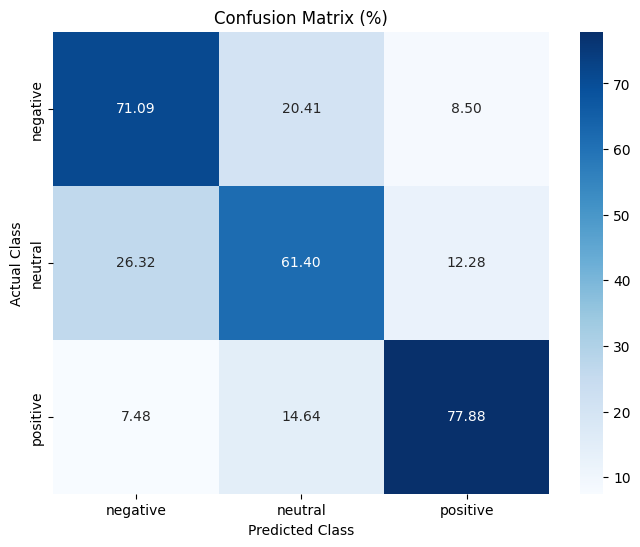

In [47]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Convert counts to percentages
cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

class_labels = encoder.classes_

plt.figure(figsize=(8, 6))
sns.heatmap(cm_percentage, annot=True, cmap='Blues', fmt='.2f', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix (%)')
plt.show()


In [52]:
new_data = ["Promoting mental health awareness and destigmatization is vital."]

new_data_tfidf = tfidf.transform(new_data)

# Make predictions
new_data_pred = logreg.predict(new_data_tfidf)

print("Predicted sentiment:", new_data_pred[0])

Predicted sentiment: 0


<h1>Support Vector Machines</h1>

In [53]:
from sklearn.svm import SVC

# Instantiate the SVM classifier
svm_classifier = SVC()

# Fit the model to the training data
svm_classifier.fit(X_train_tfidf, y_train)

SVC()

In [54]:
# Predict on test data
y_pred = svm_classifier.predict(X_test_tfidf)

# Calculate and print the accuracy score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy score:", accuracy)

Accuracy score: 0.7155555555555555


In [55]:
# Generate and print the classification report
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.68      0.72      0.70       294
           1       0.64      0.64      0.64       285
           2       0.82      0.79      0.80       321

    accuracy                           0.72       900
   macro avg       0.71      0.71      0.71       900
weighted avg       0.72      0.72      0.72       900



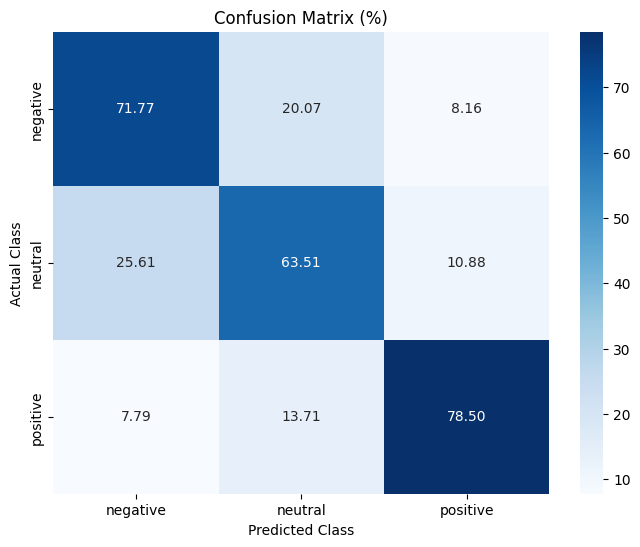

In [56]:
# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Convert counts to percentages
cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

class_labels = encoder.classes_

plt.figure(figsize=(8, 6))
sns.heatmap(cm_percentage, annot=True, cmap='Blues', fmt='.2f', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix (%)')
plt.show()

<h1>K-Nearest Neighbors</h1>

In [57]:
from sklearn.neighbors import KNeighborsClassifier

# Instantiate the K-Nearest Neighbors classifier
knn_classifier = KNeighborsClassifier()

# Fit the model to the training data
knn_classifier.fit(X_train_tfidf, y_train)

KNeighborsClassifier()

In [58]:
# Predict on test data
y_pred = knn_classifier.predict(X_test_tfidf)

# Calculate and print the accuracy score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy score:", accuracy)

Accuracy score: 0.6055555555555555


In [59]:
# Generate and print the classification report
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.55      0.60      0.57       294
           1       0.50      0.53      0.52       285
           2       0.78      0.68      0.72       321

    accuracy                           0.61       900
   macro avg       0.61      0.60      0.61       900
weighted avg       0.62      0.61      0.61       900



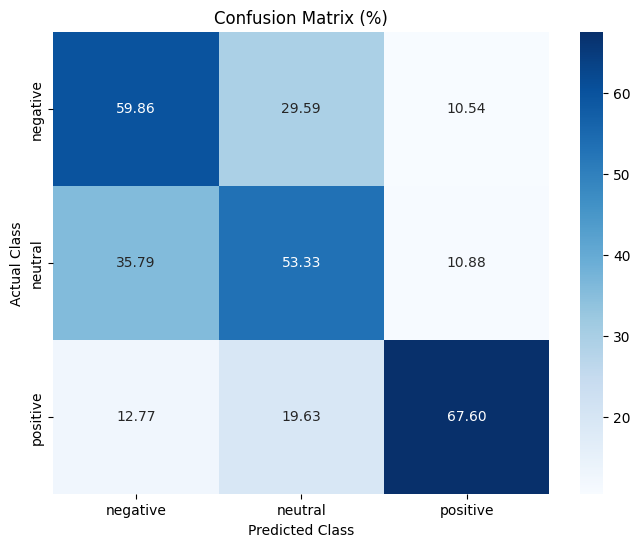

In [60]:
# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Convert counts to percentages
cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

class_labels = encoder.classes_

plt.figure(figsize=(8, 6))
sns.heatmap(cm_percentage, annot=True, cmap='Blues', fmt='.2f', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix (%)')
plt.show()

<h1>Decision Tree</h1>

In [61]:
from sklearn.tree import DecisionTreeClassifier

# Instantiate the Decision Tree classifier
tree_classifier = DecisionTreeClassifier()

# Fit the model to the training data
tree_classifier.fit(X_train_tfidf, y_train)

DecisionTreeClassifier()

In [62]:
# Predict on test data
y_pred = tree_classifier.predict(X_test_tfidf)

# Calculate and print the accuracy score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy score:", accuracy)

Accuracy score: 0.5222222222222223


In [63]:
# Generate and print the classification report
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.49      0.50      0.49       294
           1       0.44      0.46      0.45       285
           2       0.64      0.60      0.62       321

    accuracy                           0.52       900
   macro avg       0.52      0.52      0.52       900
weighted avg       0.53      0.52      0.52       900



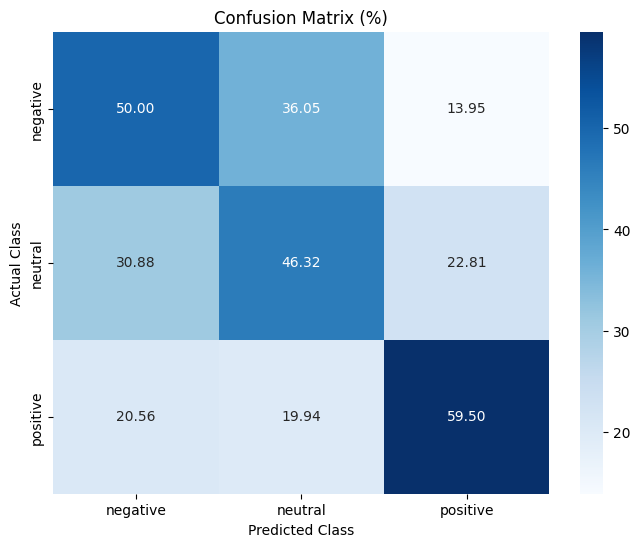

In [64]:
# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Convert counts to percentages
cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

class_labels = encoder.classes_

plt.figure(figsize=(8, 6))
sns.heatmap(cm_percentage, annot=True, cmap='Blues', fmt='.2f', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix (%)')
plt.show()

<h1>Naive Bayes</h1>

In [65]:
from sklearn.naive_bayes import MultinomialNB

# Instantiate the Naive Bayes classifier
nb_classifier = MultinomialNB()

# Fit the model to the training data
nb_classifier.fit(X_train_tfidf, y_train)

MultinomialNB()

In [66]:
# Predict on test data
y_pred = nb_classifier.predict(X_test_tfidf)

# Calculate and print the accuracy score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy score:", accuracy)

Accuracy score: 0.7066666666666667


In [67]:
# Generate and print the classification report
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.73      0.67      0.70       294
           1       0.59      0.68      0.63       285
           2       0.81      0.76      0.78       321

    accuracy                           0.71       900
   macro avg       0.71      0.70      0.71       900
weighted avg       0.71      0.71      0.71       900



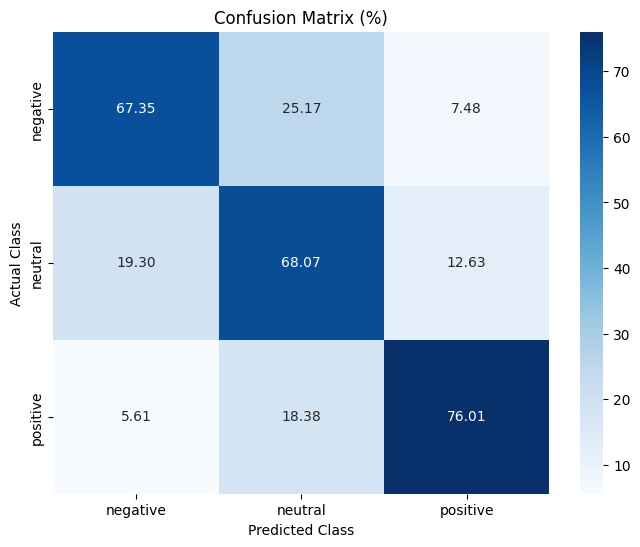

In [68]:
# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Convert counts to percentages
cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

class_labels = encoder.classes_

plt.figure(figsize=(8, 6))
sns.heatmap(cm_percentage, annot=True, cmap='Blues', fmt='.2f', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix (%)')
plt.show()

<h1>Random Forest</h1>

In [69]:
from sklearn.ensemble import RandomForestClassifier

# Instantiate the Random Forest classifier
rf_classifier = RandomForestClassifier()

# Fit the model to the training data
rf_classifier.fit(X_train_tfidf, y_train)

RandomForestClassifier()

In [70]:
# Predict on test data
y_pred = rf_classifier.predict(X_test_tfidf)

# Calculate and print the accuracy score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy score:", accuracy)

Accuracy score: 0.6788888888888889


In [71]:
# Generate and print the classification report
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.67      0.69      0.68       294
           1       0.60      0.60      0.60       285
           2       0.76      0.74      0.75       321

    accuracy                           0.68       900
   macro avg       0.68      0.68      0.68       900
weighted avg       0.68      0.68      0.68       900



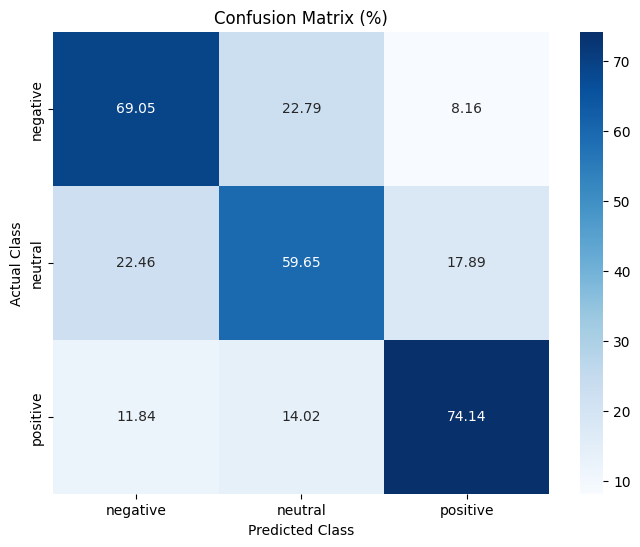

In [72]:
# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Convert counts to percentages
cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

class_labels = encoder.classes_

plt.figure(figsize=(8, 6))
sns.heatmap(cm_percentage, annot=True, cmap='Blues', fmt='.2f', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix (%)')
plt.show()

<h1>Gradient Boosting</h1>

In [73]:
from sklearn.ensemble import GradientBoostingClassifier

# Instantiate the Gradient Boosting classifier
gb_classifier = GradientBoostingClassifier()

# Fit the model to the training data
gb_classifier.fit(X_train_tfidf, y_train)

GradientBoostingClassifier()

In [74]:
# Predict on test data
y_pred = gb_classifier.predict(X_test_tfidf)

# Calculate and print the accuracy score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy score:", accuracy)

Accuracy score: 0.6533333333333333


In [75]:
# Generate and print the classification report
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.64      0.68      0.66       294
           1       0.57      0.59      0.58       285
           2       0.76      0.68      0.72       321

    accuracy                           0.65       900
   macro avg       0.66      0.65      0.65       900
weighted avg       0.66      0.65      0.66       900



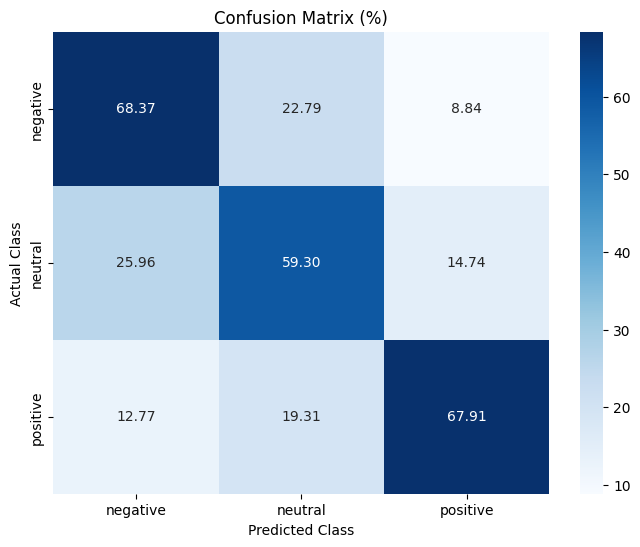

In [76]:
# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Convert counts to percentages
cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

class_labels = encoder.classes_

plt.figure(figsize=(8, 6))
sns.heatmap(cm_percentage, annot=True, cmap='Blues', fmt='.2f', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix (%)')
plt.show()